In [1]:
from src import Plot, meanBy, printMeanDecrease, printMeanLearningTimeDecrease
import pandas as pd

cancellationMixedPath = "data/mixedEq/cancellation_mixed.csv"
commutativeMixedPath = "data/mixedEq/commutation_mixed.csv"
commutativeMixedIncreasedAlphabetPath = "data/mixedEq/commutation_mixed_increased_alphabet.csv"
idempotencyMixedPath = "data/mixedEq/idempotency_mixed.csv"

cancellationExactPath = "data/exactEq/cancellation_increasing_number_of_states.csv"
commutativeExactPath = "data/exactEq/commutation_increasing_number_of_states.csv"
idempotencyExactPath = "data/exactEq/idempotency_increasing_number_of_states.csv"


def addMeanComparison(plot, mixedPath, exactPath, yColumn, scale=1):
    filters = exactFilters(mixedPath)

    plot.add(
        mixedPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={"useSrs": 0},
        ) / scale,
        label="Mixed EQ without SRS",
    )
    plot.add(
        mixedPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={"useSrs": 1},
        ) / scale,
        label="Mixed EQ with SRS",
    )
    plot.add(
        exactPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={**filters, "useSrs": 0},
        ) / scale,
        label="Exact EQ without SRS",
    )
    plot.add(
        exactPath,
        lambda data: meanBy(
            data,
            xColumn="targetNumOfStates",
            yColumn=yColumn,
            filters={**filters, "useSrs": 1},
        ) / scale,
        label="Exact EQ with SRS",
    )


def exactFilters(mixedPath):
    mixedData = pd.read_csv(mixedPath)
    return {"targetNumOfStates": mixedData["targetNumOfStates"].unique().tolist()}


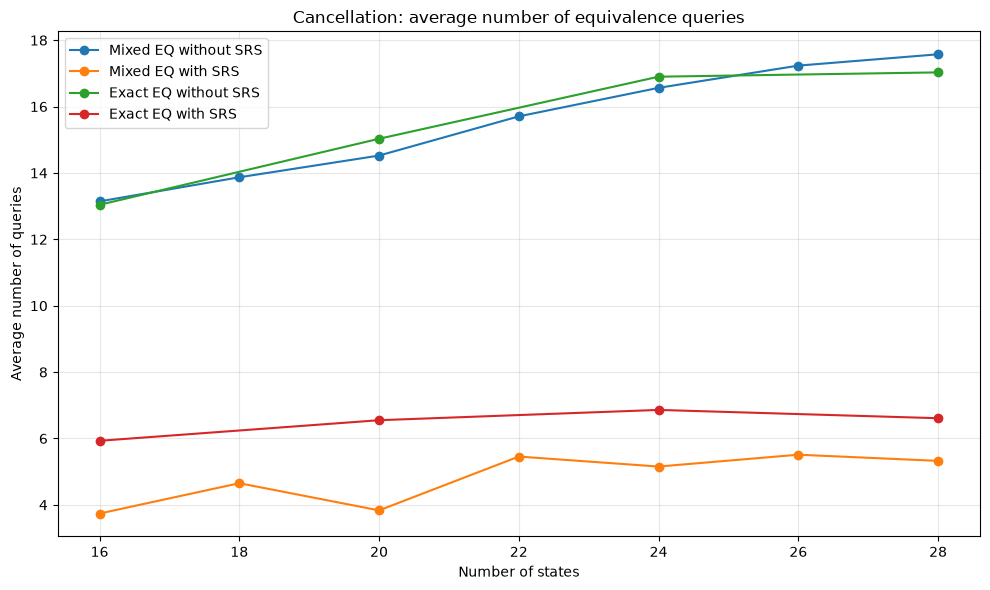

In [2]:
cancellationQueriesPlot = Plot(
    title="Cancellation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    cancellationQueriesPlot,
    cancellationMixedPath,
    cancellationExactPath,
    yColumn="equivalenceQueryCount",
)
cancellationQueriesPlot.draw()

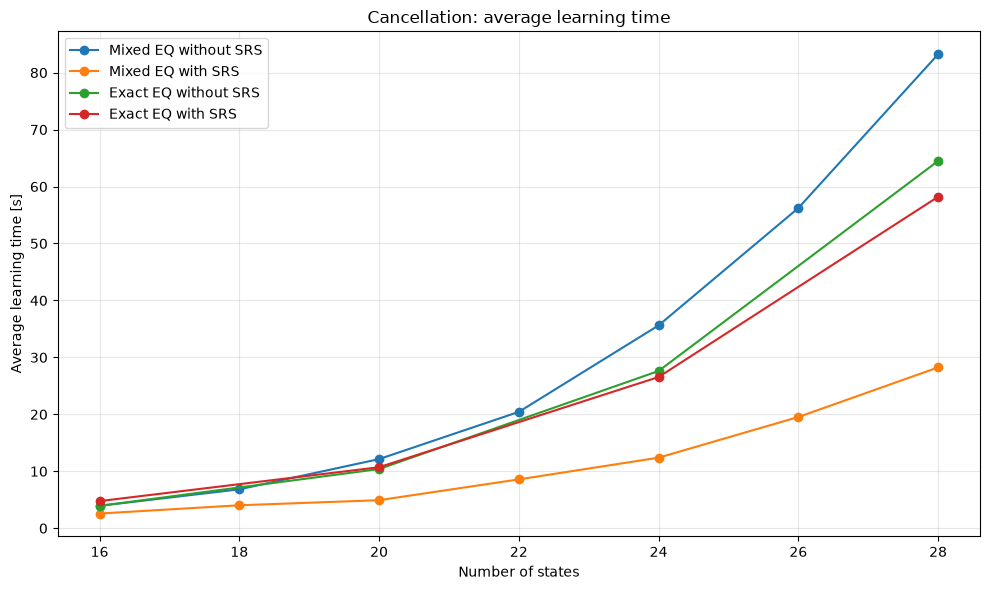

In [3]:
cancellationTimePlot = Plot(
    title="Cancellation: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    cancellationTimePlot,
    cancellationMixedPath,
    cancellationExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
cancellationTimePlot.draw()

In [4]:
print("Mixed EQ")
printMeanDecrease(cancellationMixedPath)
printMeanLearningTimeDecrease(cancellationMixedPath)

print("Exact EQ")
filters = exactFilters(cancellationMixedPath)
printMeanDecrease(cancellationExactPath, filters)
printMeanLearningTimeDecrease(cancellationExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 68.92%
Average procentage reduction in learning time 63.15%
Exact EQ
Average procentage reduction in equivalence queries 58.15%
Average procentage reduction in learning time 5.82%


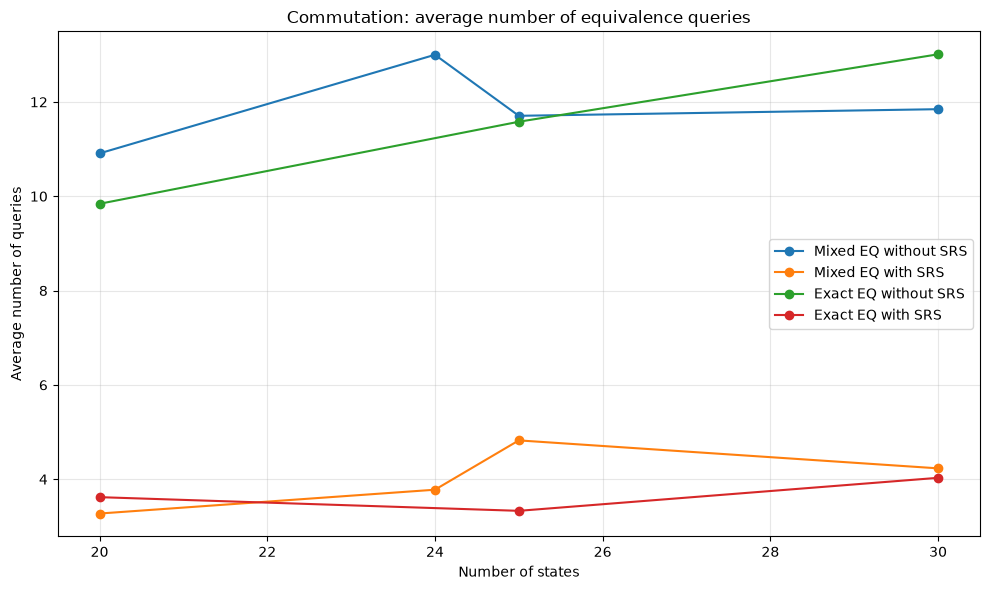

In [16]:
commutationQueriesPlot = Plot(
    title="Commutation: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutationQueriesPlot,
    commutativeMixedPath,
    commutativeExactPath,
    yColumn="equivalenceQueryCount",
)
commutationQueriesPlot.draw()

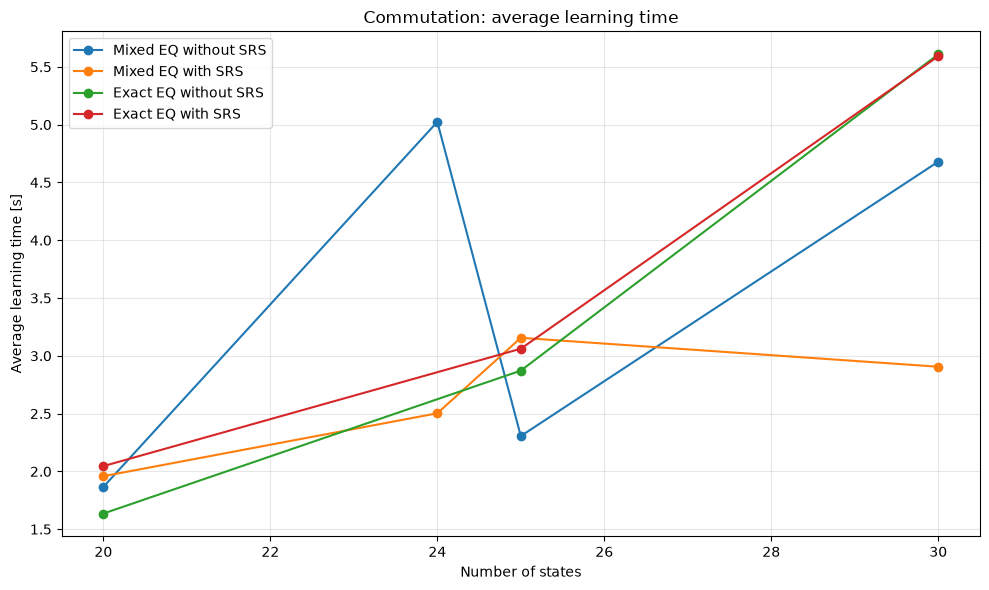

In [15]:
commutationTimePlot = Plot(
    title="Commutation: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    commutationTimePlot,
    commutativeMixedPath,
    commutativeExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
commutationTimePlot.draw()

In [17]:
print("Mixed EQ")
printMeanDecrease(commutativeMixedPath)
printMeanLearningTimeDecrease(commutativeMixedPath)

print("Exact EQ")
filters = exactFilters(commutativeMixedPath)
printMeanDecrease(commutativeExactPath, filters)
printMeanLearningTimeDecrease(commutativeExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 64.92%
Average procentage reduction in learning time 18.27%
Exact EQ
Average procentage reduction in equivalence queries 68.11%
Average procentage reduction in learning time -5.76%


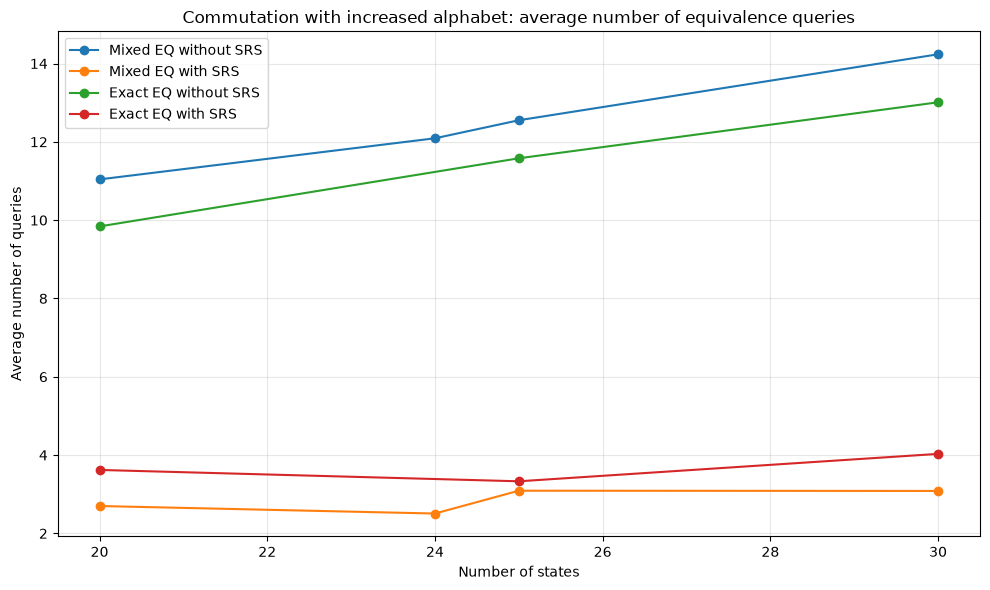

In [12]:
commutationIncreasedAlphabetQueriesPlot = Plot(
    title="Commutation with increased alphabet: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    commutationIncreasedAlphabetQueriesPlot,
    commutativeMixedIncreasedAlphabetPath,
    commutativeExactPath,
    yColumn="equivalenceQueryCount",
)
commutationIncreasedAlphabetQueriesPlot.draw()

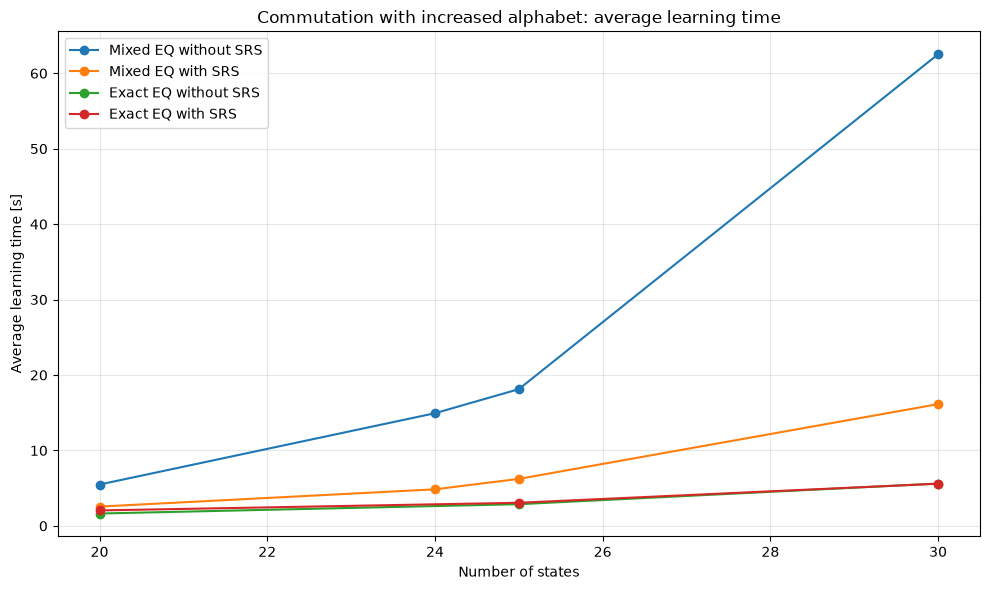

In [13]:
commutationIncreasedAlphabetTimePlot = Plot(
    title="Commutation with increased alphabet: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    commutationIncreasedAlphabetTimePlot,
    commutativeMixedIncreasedAlphabetPath,
    commutativeExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
commutationIncreasedAlphabetTimePlot.draw()

In [14]:
print("Mixed EQ")
printMeanDecrease(commutativeMixedIncreasedAlphabetPath)
printMeanLearningTimeDecrease(commutativeMixedIncreasedAlphabetPath)

print("Exact EQ")
filters = exactFilters(commutativeMixedIncreasedAlphabetPath)
printMeanDecrease(commutativeExactPath, filters)
printMeanLearningTimeDecrease(commutativeExactPath, filters)

Mixed EQ
Average procentage reduction in equivalence queries 77.20%
Average procentage reduction in learning time 70.43%
Exact EQ
Average procentage reduction in equivalence queries 68.11%
Average procentage reduction in learning time -5.76%


In [ ]:
idempotencyQueriesPlot = Plot(
    title="Idempotency: average number of equivalence queries",
    xLabel="Number of states",
    yLabel="Average number of queries",
)
addMeanComparison(
    idempotencyQueriesPlot,
    idempotencyMixedPath,
    idempotencyExactPath,
    yColumn="equivalenceQueryCount",
)
idempotencyQueriesPlot.draw()

In [ ]:
idempotencyTimePlot = Plot(
    title="Idempotency: average learning time",
    xLabel="Number of states",
    yLabel="Average learning time [s]",
)
addMeanComparison(
    idempotencyTimePlot,
    idempotencyMixedPath,
    idempotencyExactPath,
    yColumn="learnerTimeUs",
    scale=1_000_000,
)
idempotencyTimePlot.draw()

In [ ]:
print("Mixed EQ")
printMeanDecrease(idempotencyMixedPath)
printMeanLearningTimeDecrease(idempotencyMixedPath)

print("Exact EQ")
filters = exactFilters(idempotencyMixedPath)
printMeanDecrease(idempotencyExactPath, filters)
printMeanLearningTimeDecrease(idempotencyExactPath, filters)